Experiment 6: Deep NLP using TensorFlow and Keras

Aim:To implement Deep Natural Language Processing (NLP) using TensorFlow and Keras for text classification.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape  : (25000, 200)
Testing Shape   : (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 463ms/step - accuracy: 0.5450 - loss: 0.6829 - val_accuracy: 0.5746 - val_loss: 0.6516
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 451ms/step - accuracy: 0.6445 - loss: 0.5873 - val_accuracy: 0.6964 - val_loss: 0.5868
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 476ms/step - accuracy: 0.7564 - loss: 0.5067 - val_accuracy: 0.7186 - val_loss: 0.5606
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 206s 488ms/step - accuracy: 0.6849 - loss: 0.5366 - val_accuracy: 0.7234 - val_loss: 0.6209
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 194s 461ms/step - accuracy: 0.8174 - loss: 0.4397 - val_accuracy: 0.8092 - val_loss: 0.4734

Test Loss     : 0.4737
Test Accuracy : 0.8088


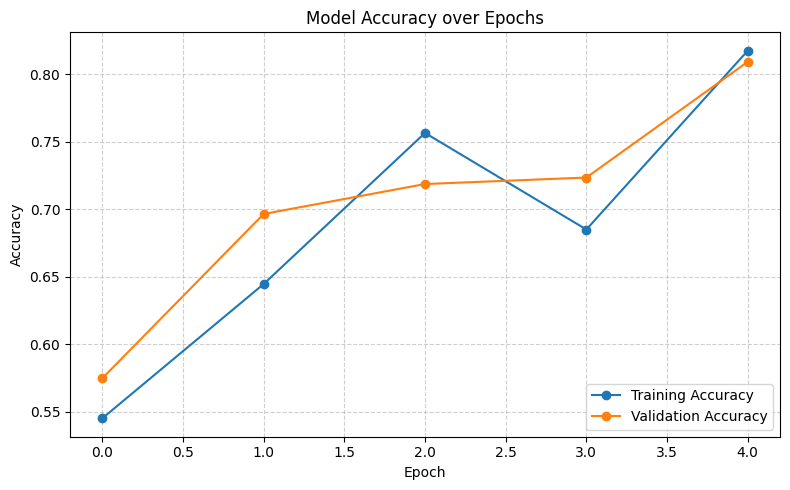

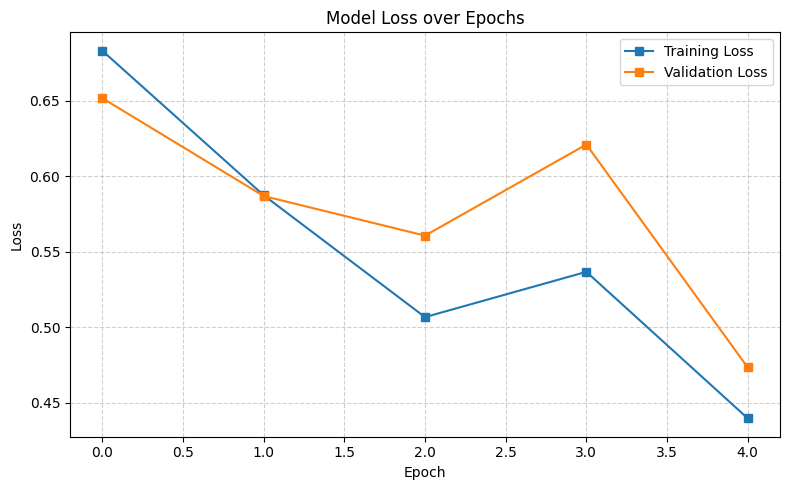

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, Dropout    # Condensed imports

import matplotlib.pyplot as plt

# Vocabulary Size
vocab_size = 10000

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding Sequences
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length, padding='post')    # Explicit padding side
X_test  = pad_sequences(X_test,  maxlen=max_length, padding='post')

print(f"Training Shape  : {X_train.shape}")
print(f"Testing Shape   : {X_test.shape}")

# Build Deep NLP Model
model = Sequential([

    # Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    # LSTM Layer
    LSTM(128, return_sequences=False),

    # Dropout Layer
    Dropout(0.5),

    # Hidden Dense Layer
    Dense(64, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),   # Explicit learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Plot Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'],     label='Training Accuracy',   marker='o', linewidth=1.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=1.5)

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'],     label='Training Loss',   marker='s', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', linewidth=1.5)

plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Conclusion: Successfully implemented Deep NLP using Embedding and LSTM layers for sentiment classification on the IMDB movie review dataset.